# 🍷 Wine Quality Prediction: ML for Food Safety & Quality Assurance

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting wine quality from physicochemical properties to support food safety standards and export compliance  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting wine quality ratings from laboratory measurements including acidity, sugar, sulphites, alcohol content, and density. The model supports **automated quality grading**, **export compliance screening**, and **food safety monitoring**.

### Government Policy Context
- **FSANZ (Food Standards Australia New Zealand)** — Food Standards Code, chemical limits in beverages, labelling compliance
- **Wine Australia** — Export eligibility, Geographic Indications, Label Integrity Program
- **DAFF (Dept of Agriculture)** — Wine export certification, biosecurity, import compliance
- **ACCC** — Consumer protection, misleading labelling, premium claims verification
- **ATO** — Wine Equalisation Tax (WET) compliance, cellar door rebate integrity

### Operational Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| Premium quality (7-9) | Fast-track export certification, premium labelling approved | Wine Australia |
| Standard quality (5-6) | Routine compliance check, standard labelling | FSANZ inspector |
| Below standard (3-4) | Enhanced testing, potential recall/relabelling | Food safety officer |
| Quality anomaly | Full laboratory re-analysis, investigate production fault | Winemaker + regulator |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
all_csvs = []
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            all_csvs.append(full_path)

if len(all_csvs) == 0:
    raise FileNotFoundError("No CSV found")

# If multiple CSVs, try to combine red and white wine
if len(all_csvs) >= 2:
    dfs = []
    for csv_path in all_csvs:
        with open(csv_path, 'r') as fh:
            sample = fh.read(2048)
        sep = ';' if sample.count(';') > sample.count(',') else ','
        temp_df = pd.read_csv(csv_path, sep=sep)
        wine_type = 'red' if 'red' in csv_path.lower() else 'white'
        temp_df['wine_type'] = wine_type
        dfs.append(temp_df)
        print(f"  Loaded {csv_path}: {temp_df.shape}")
    df = pd.concat(dfs, ignore_index=True)
    print(f"\nCombined: {df.shape[0]:,} rows x {df.shape[1]} columns")
else:
    data_path = all_csvs[0]
    with open(data_path, 'r') as fh:
        sample = fh.read(2048)
    sep = ';' if sample.count(';') > sample.count(',') else ','
    df = pd.read_csv(data_path, sep=sep)
    print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


  Found: /kaggle/input/datasets/organizations/uciml/red-wine-quality-cortez-et-al-2009/winequality-red.csv

Loaded: 1,599 rows x 12 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:30s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls:3d}")
df.head()


COLUMN SUMMARY
   0. fixed acidity                  | float64    | unique=   96 | nulls=  0
   1. volatile acidity               | float64    | unique=  143 | nulls=  0
   2. citric acid                    | float64    | unique=   80 | nulls=  0
   3. residual sugar                 | float64    | unique=   91 | nulls=  0
   4. chlorides                      | float64    | unique=  153 | nulls=  0
   5. free sulfur dioxide            | float64    | unique=   60 | nulls=  0
   6. total sulfur dioxide           | float64    | unique=  144 | nulls=  0
   7. density                        | float64    | unique=  436 | nulls=  0
   8. pH                             | float64    | unique=   89 | nulls=  0
   9. sulphates                      | float64    | unique=   96 | nulls=  0
  10. alcohol                        | float64    | unique=   65 | nulls=  0
  11. quality                        | int64      | unique=    6 | nulls=  0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Target Variable Analysis

In [4]:
# Known target: 'quality'
target_candidates = ['quality', 'Quality', 'target', 'Target', 'class', 'Class', 'rating']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

print(f"\nRaw distribution:")
print(df[target_col].value_counts().sort_index())

# Remap to sequential 0-based labels for XGBoost
unique_classes = sorted(df[target_col].unique())
n_classes = len(unique_classes)
class_map = {old: new for new, old in enumerate(unique_classes)}
original_labels = {new: old for old, new in class_map.items()}
df[target_col] = df[target_col].map(class_map)
target_labels = [f'Quality {original_labels[i]}' for i in range(n_classes)]

print(f"\nRemapped: {class_map}")
print(f"\nFinal distribution:")
print(df[target_col].value_counts().sort_index())
print(f"\nClasses: {n_classes}, Labels: {target_labels}")


Found target: 'quality'

Raw distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Remapped: {np.int64(3): 0, np.int64(4): 1, np.int64(5): 2, np.int64(6): 3, np.int64(7): 4, np.int64(8): 5}

Final distribution:
quality
0     10
1     53
2    681
3    638
4    199
5     18
Name: count, dtype: int64

Classes: 6, Labels: ['Quality 3', 'Quality 4', 'Quality 5', 'Quality 6', 'Quality 7', 'Quality 8']


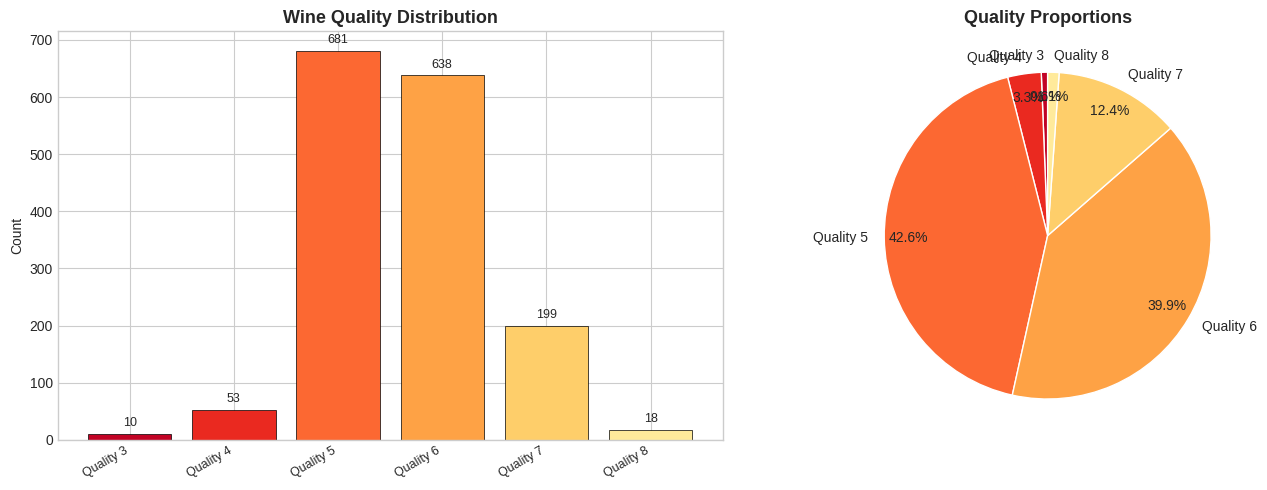

AU context: Australia is 5th largest wine exporter globally (~$2.9B exports, Wine Australia).
Wine Australia administers the Label Integrity Program for all exported wines.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
colors = sns.color_palette('YlOrRd_r', n_colors=len(vc))
axes[0].bar(range(len(vc)), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(target_labels, rotation=30, ha='right', fontsize=9)
axes[0].set_title('Wine Quality Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + max(vc.values)*0.02, str(v), ha='center', fontsize=9)
axes[1].pie(vc.values, labels=target_labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[1].set_title('Quality Proportions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: Australia is 5th largest wine exporter globally (~$2.9B exports, Wine Australia).")
print("Wine Australia administers the Label Integrity Program for all exported wines.")


## 3. Exploratory Data Analysis

Key questions for food safety & quality:
- Which chemical properties most influence quality ratings?
- Are there safe limits for sulphites, acidity, volatile acidity?
- Does alcohol content correlate with perceived quality?
- Do red and white wines show different quality patterns?


Numeric features (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


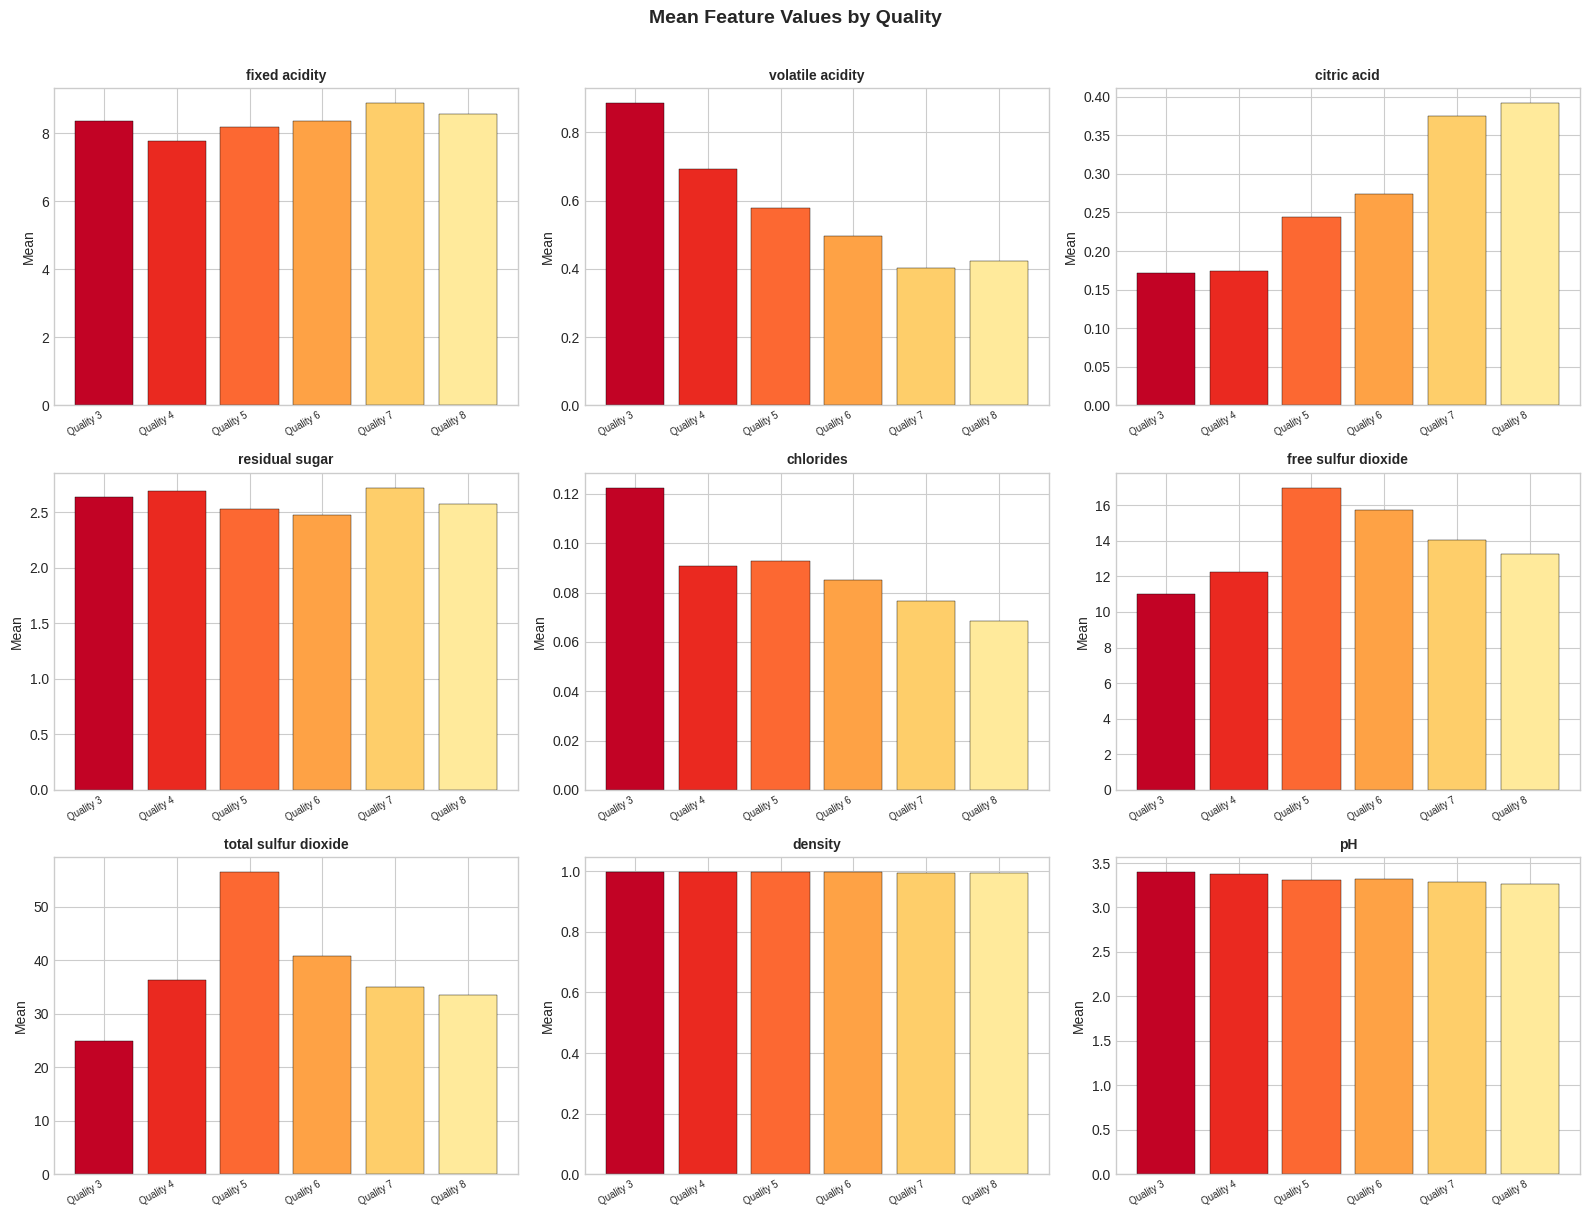

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

plot_cols = numeric_cols[:9]
if len(plot_cols) > 0:
    n_rows_p = (len(plot_cols) + 2) // 3
    fig, axes = plt.subplots(n_rows_p, 3, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        # Show mean by quality
        means = df.groupby(target_col)[col].mean()
        axes[i].bar(range(len(means)), means.values, color=colors, edgecolor='black', linewidth=0.3)
        axes[i].set_xticks(range(len(means)))
        axes[i].set_xticklabels([target_labels[j] for j in means.index], rotation=30, ha='right', fontsize=7)
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].set_ylabel('Mean')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Mean Feature Values by Quality', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_by_quality.png', dpi=150, bbox_inches='tight'); plt.show()


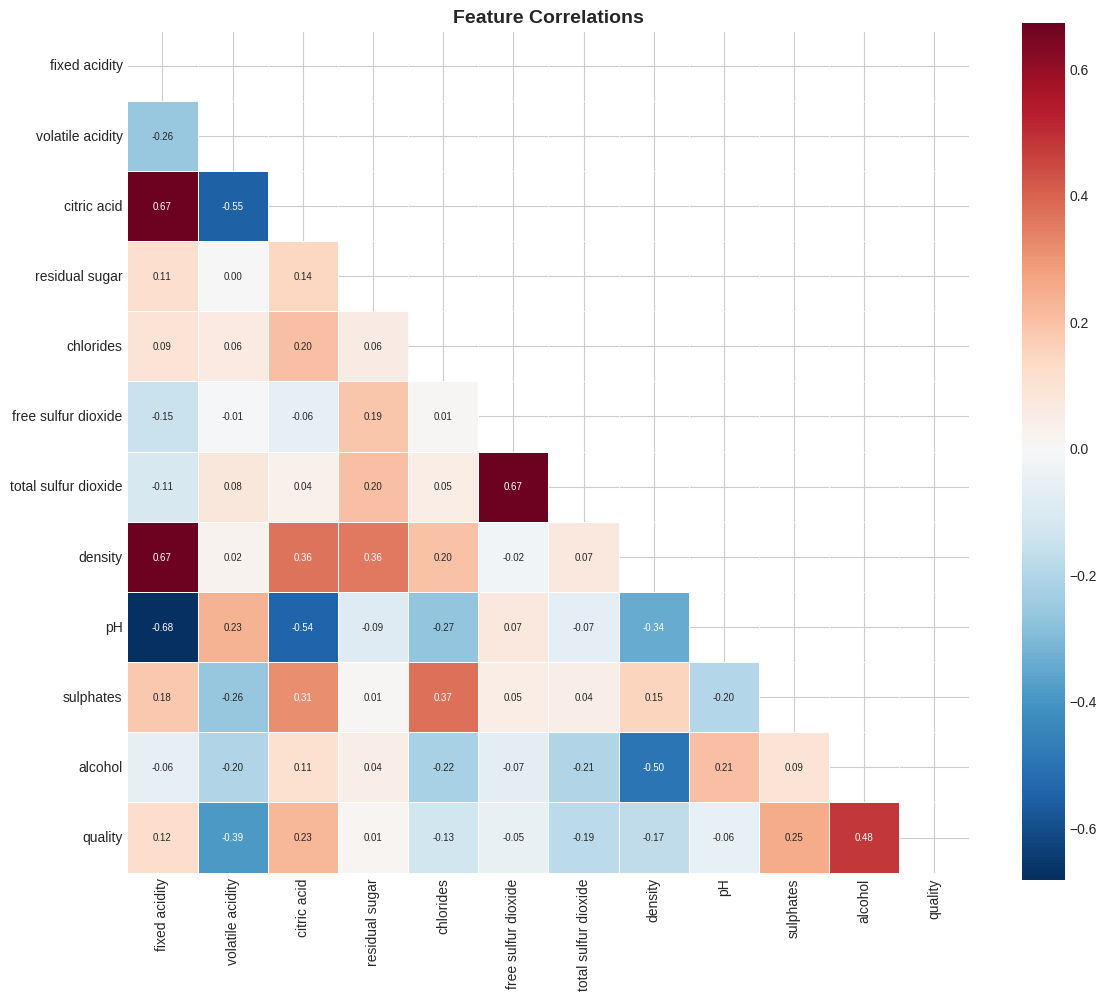

Correlations with quality:
  alcohol                        +0.4762
  volatile acidity               -0.3906
  sulphates                      +0.2514
  citric acid                    +0.2264
  total sulfur dioxide           -0.1851
  density                        -0.1749
  chlorides                      -0.1289
  fixed acidity                  +0.1241
  pH                             -0.0577
  free sulfur dioxide            -0.0507
  residual sugar                 +0.0137


In [7]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols + [target_col]].corr()
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
    ax.set_title('Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print("Correlations with quality:")
    for feat, val in target_corr.items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:30s} {direction}{val:.4f}")


In [8]:
# Wine type analysis if present
if 'wine_type' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ct = pd.crosstab(df['wine_type'], df[target_col], normalize='index')
    ct.columns = target_labels
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='YlOrRd_r', edgecolor='black', linewidth=0.3)
    ax.set_title('Quality Distribution by Wine Type', fontsize=13, fontweight='bold')
    ax.set_ylabel('Proportion'); ax.tick_params(axis='x', rotation=0)
    plt.tight_layout(); plt.savefig('wine_type_quality.png', dpi=150, bbox_inches='tight'); plt.show()


## 4. Feature Engineering & Preprocessing

In [9]:
df_model = df.copy()

# Encode wine_type if present
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

# Feature engineering
composites_added = []

# Total acidity
if 'fixed acidity' in X.columns and 'volatile acidity' in X.columns:
    X['total_acidity'] = X['fixed acidity'] + X['volatile acidity']
    composites_added.append('total_acidity')
    print("Created 'total_acidity'")

# Free SO2 ratio
if 'free sulfur dioxide' in X.columns and 'total sulfur dioxide' in X.columns:
    X['free_so2_ratio'] = X['free sulfur dioxide'] / (X['total sulfur dioxide'] + 1)
    composites_added.append('free_so2_ratio')
    print("Created 'free_so2_ratio'")

# Sugar-alcohol balance
if 'residual sugar' in X.columns and 'alcohol' in X.columns:
    X['sugar_alcohol_ratio'] = X['residual sugar'] / (X['alcohol'] + 1)
    composites_added.append('sugar_alcohol_ratio')
    print("Created 'sugar_alcohol_ratio'")

# Sulphite safety flag (FSANZ limit 300mg/L for wine)
if 'total sulfur dioxide' in X.columns:
    X['high_sulphite'] = (X['total sulfur dioxide'] > 200).astype(int)
    composites_added.append('high_sulphite')
    print("Created 'high_sulphite' (>200 mg/L)")

print(f"\nEngineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")
print(f"Target classes: {np.unique(y)}")


Created 'total_acidity'
Created 'free_so2_ratio'
Created 'sugar_alcohol_ratio'
Created 'high_sulphite' (>200 mg/L)

Engineered: 4
Final feature count: 15
Target classes: [0 1 2 3 4 5]


## 5. Model Training & Cross-Validation

In [10]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42, multi_class='multinomial'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_kappa = [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        fold_preds[val_idx] = y_pred
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='weighted')
        kappa = cohen_kappa_score(y_val, y_pred)
        fold_acc.append(acc); fold_f1.append(f1); fold_kappa.append(kappa)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1(w)={f1:.4f}  Kappa={kappa:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'kappa_mean': np.mean(fold_kappa),
        'time': elapsed, 'oof_preds': fold_preds}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  Kappa: {np.mean(fold_kappa):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.5685  F1(w)=0.5388  Kappa=0.2822
  Fold 2: Acc=0.6116  F1(w)=0.5899  Kappa=0.3623
  Fold 3: Acc=0.5966  F1(w)=0.5719  Kappa=0.3355
  -- Acc: 0.5922  F1: 0.5669  Kappa: 0.3267  Time: 3.62s

Training: Random Forest
  Fold 1: Acc=0.6735  F1(w)=0.6558  Kappa=0.4664
  Fold 2: Acc=0.7054  F1(w)=0.6870  Kappa=0.5201
  Fold 3: Acc=0.6660  F1(w)=0.6459  Kappa=0.4564
  -- Acc: 0.6817  F1: 0.6629  Kappa: 0.4810  Time: 1.19s

Training: XGBoost
  Fold 1: Acc=0.6529  F1(w)=0.6401  Kappa=0.4417
  Fold 2: Acc=0.6979  F1(w)=0.6885  Kappa=0.5169
  Fold 3: Acc=0.6548  F1(w)=0.6396  Kappa=0.4412
  -- Acc: 0.6685  F1: 0.6561  Kappa: 0.4666  Time: 1.34s

Training: LightGBM
  Fold 1: Acc=0.6585  F1(w)=0.6441  Kappa=0.4478
  Fold 2: Acc=0.6942  F1(w)=0.6831  Kappa=0.5091
  Fold 3: Acc=0.6717  F1(w)=0.6548  Kappa=0.4707
  -- Acc: 0.6748  F1: 0.6607  Kappa: 0.4759  Time: 1.88s


## 6. Model Comparison & Selection

In [12]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1 (weighted)': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'Kappa': f"{res['kappa_mean']:.4f}",
        'Time': f"{res['time']:.2f}s",
        'sort_val': res['f1_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('sort_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 90)
print(summary_df[['Model', 'Accuracy', 'F1 (weighted)', 'Kappa', 'Time']].to_string(index=False))
print("=" * 90)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy     F1 (weighted)  Kappa  Time
      Random Forest 0.6817 +/- 0.0171 0.6629 +/- 0.0175 0.4810 1.19s
           LightGBM 0.6748 +/- 0.0147 0.6607 +/- 0.0164 0.4759 1.88s
            XGBoost 0.6685 +/- 0.0208 0.6561 +/- 0.0229 0.4666 1.34s
Logistic Regression 0.5922 +/- 0.0179 0.5669 +/- 0.0212 0.3267 3.62s

Best model: Random Forest


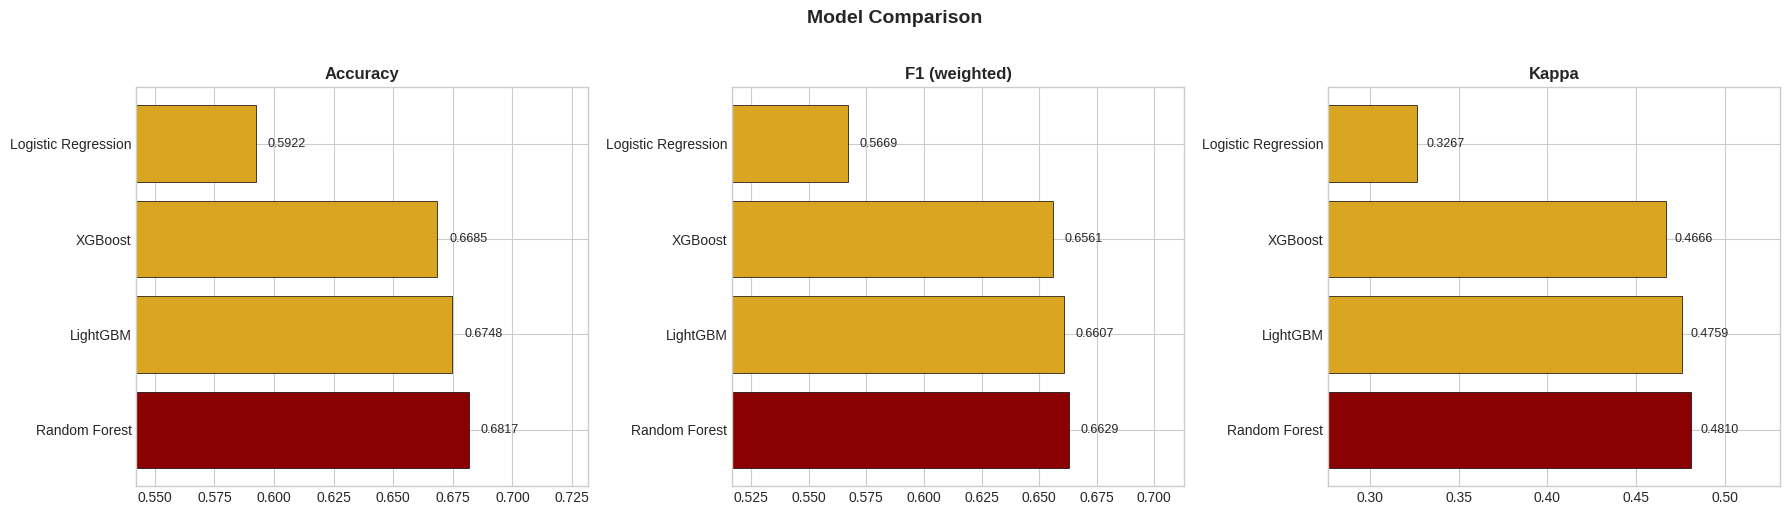

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
bar_colors = ['#8B0000' if m == best_model_name else '#DAA520' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'kappa_mean'], ['Accuracy', 'F1 (weighted)', 'Kappa']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=bar_colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.05)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis

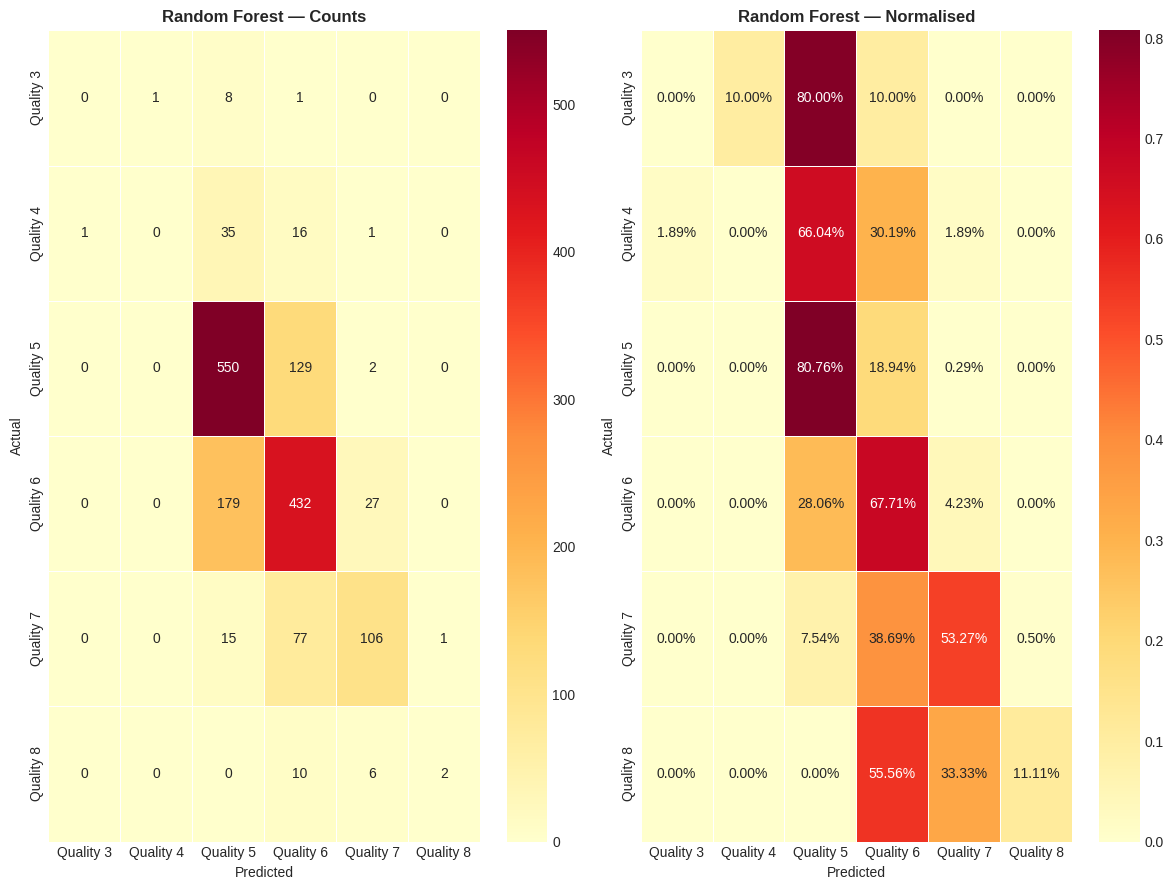


              precision    recall  f1-score   support

   Quality 3       0.00      0.00      0.00        10
   Quality 4       0.00      0.00      0.00        53
   Quality 5       0.70      0.81      0.75       681
   Quality 6       0.65      0.68      0.66       638
   Quality 7       0.75      0.53      0.62       199
   Quality 8       0.67      0.11      0.19        18

    accuracy                           0.68      1599
   macro avg       0.46      0.35      0.37      1599
weighted avg       0.66      0.68      0.66      1599


Note: Adjacent quality misclassifications (e.g., 5 vs 6) are less concerning than
extreme errors (e.g., 3 classified as 8). Wine quality is inherently subjective.


In [14]:
best_preds = results[best_model_name]['oof_preds']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(max(10, n_classes*2), max(6, n_classes*1.5)))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', xticklabels=target_labels, yticklabels=target_labels,
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd', xticklabels=target_labels, yticklabels=target_labels,
            ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=target_labels)}")
print("\nNote: Adjacent quality misclassifications (e.g., 5 vs 6) are less concerning than")
print("extreme errors (e.g., 3 classified as 8). Wine quality is inherently subjective.")


## 8. Feature Importance & Policy Insights

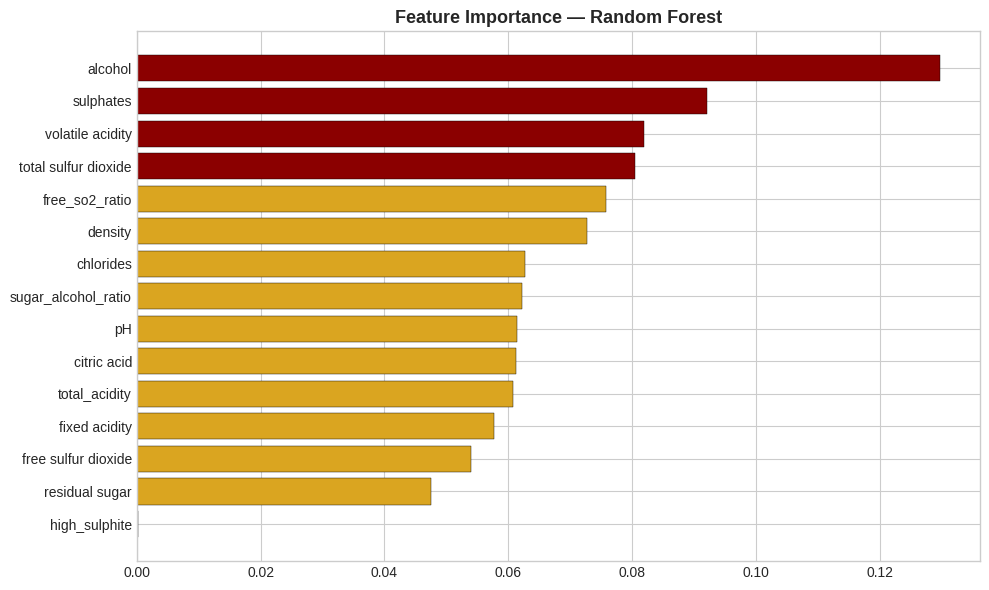

TOP 5 QUALITY PREDICTORS
  alcohol                         0.1297
  sulphates                       0.0921
  volatile acidity                0.0819
  total sulfur dioxide            0.0804
  free_so2_ratio                  0.0757

Policy insight: Alcohol content and volatile acidity are key quality drivers.
FSANZ monitors sulphite levels (limit 300mg/L) — reflected in SO2 features.


In [15]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['f1_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.4)))
    colors_imp = ['#8B0000' if imp > feat_imp['Importance'].quantile(0.75) else '#DAA520' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 QUALITY PREDICTORS")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:30s}  {row['Importance']:.4f}")
    print("\nPolicy insight: Alcohol content and volatile acidity are key quality drivers.")
    print("FSANZ monitors sulphite levels (limit 300mg/L) — reflected in SO2 features.")


## 9. Deployment Readiness & Production Considerations

In [16]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  Accuracy:             {best_res['accuracy_mean']:.4f}")
print(f"  F1 (weighted):        {best_res['f1_mean']:.4f}")
print(f"  Cohen's Kappa:        {best_res['kappa_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  Quality classes:      {n_classes}")
print(f"  CV strategy:          3-fold Stratified")
print("=" * 60)
checks = {
    'Accuracy > 0.50': best_res['accuracy_mean'] > 0.50,
    'F1 > 0.50': best_res['f1_mean'] > 0.50,
    'Kappa > 0.20': best_res['kappa_mean'] > 0.20,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Feature importance available': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Random Forest
  Accuracy:             0.6817
  F1 (weighted):        0.6629
  Cohen's Kappa:        0.4810
  Training time:        1.2s
  Feature count:        15
  Dataset rows:         1,599
  Quality classes:      6
  CV strategy:          3-fold Stratified

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] Accuracy > 0.50
  [pass] F1 > 0.50
  [pass] Kappa > 0.20
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Feature importance available
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [17]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: Winery laboratory LIMS, Wine Australia certification system
   Ingestion: API -> Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (lab results, GI metadata, vintage)
   Schedule: Per-batch at bottling + pre-export certification

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time at laboratory result submission (<500ms)
   Output: Quality grade + confidence + flagged chemical anomalies
   Batch: Annual vintage quality analytics for Wine Australia

3. INTEGRATION POINTS
   Wine Australia: Export certification decision support
   FSANZ: Chemical limit compliance screening (sulphites, acids)
   Customs/DAFF: Export documentation quality verification
   Wineries: Inline quality control during production
   Retailers: Premium/standard classification for pricing

4. GOVERNANCE
   FSANZ compliance: All chemical measurements within Food Standards Code
   Wine Australia: Label Integrity Program alignment
   Subjectivity: Quality ratings inherently subjective — model is advisory
   Calibration: Annual recalibration against expert panel assessments
   GI protection: Model must not undermine Geographic Indication claims

5. MONITORING & RETRAINING
   Drift: PSI on chemical measurements per vintage
   Performance: Kappa against expert panel ratings annually
   Retraining: Annual with new vintage expert assessments
   Vintage variation: Climate-adjusted baselines per region
   New varieties: Expand training data for emerging grape varieties

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: Winery laboratory LIMS, Wine Australia certification system
   Ingestion: API -> Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (lab results, GI metadata, vintage)
   Schedule: Per-batch at bottling + pre-export certification

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time at laboratory result submission (<500ms)
   Output: Quality grade + confidence + flagged chemical anomalies
   Batch: Annual vintage quality analytics for Wine Australia

3. INTEGRATION POINTS
   Wine Australia: Export certification decision support
   FSANZ: Chemical limit compliance screening (sulphites, acids)
   Customs/DAFF: Export documentation quality verification
   Wineries: Inline quality control during production
   Retailers: Premium/standard classification for pricing

4. GOVERNANCE
   FSANZ compliance: All chemical measurements within Food Standards Code
   Wine Australia: